In [1]:
import pandas as pd
import matplotlib.pyplot as plot

In [10]:
df = pd.read_csv("../data/sales_data_2000_rows.csv")

In [11]:
print(df.head())

   Order_ID        Date  Product     Category       City  Quantity  Price
0      1001  2025-02-19  Printer  Electronics    Kolkata         3   9591
1      1002  2025-08-08      Pen   Stationery  Hyderabad         5    318
2      1003  2025-07-28    Mouse  Electronics    Chennai         1    697
3      1004  2025-08-15    Chair    Furniture  Ahmedabad         1   3410
4      1005  2025-04-12    Mouse  Electronics     Mumbai         2    624


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order_ID  2000 non-null   int64
 1   Date      2000 non-null   str  
 2   Product   2000 non-null   str  
 3   Category  2000 non-null   str  
 4   City      2000 non-null   str  
 5   Quantity  2000 non-null   int64
 6   Price     2000 non-null   int64
dtypes: int64(3), str(4)
memory usage: 109.5 KB
None


In [13]:
print(df.isnull().sum())

Order_ID    0
Date        0
Product     0
Category    0
City        0
Quantity    0
Price       0
dtype: int64


In [15]:
print(df.drop_duplicates())

      Order_ID        Date   Product     Category       City  Quantity  Price
0         1001  2025-02-19   Printer  Electronics    Kolkata         3   9591
1         1002  2025-08-08       Pen   Stationery  Hyderabad         5    318
2         1003  2025-07-28     Mouse  Electronics    Chennai         1    697
3         1004  2025-08-15     Chair    Furniture  Ahmedabad         1   3410
4         1005  2025-04-12     Mouse  Electronics     Mumbai         2    624
...        ...         ...       ...          ...        ...       ...    ...
1995      2996  2025-12-26      Sofa    Furniture  Ahmedabad         4  15124
1996      2997  2025-02-27  Notebook   Stationery  Ahmedabad         3    160
1997      2998  2025-04-25     Chair    Furniture      Delhi         3   3590
1998      2999  2025-10-18   Monitor  Electronics     Mumbai         2   8550
1999      3000  2025-05-29       Bag  Accessories    Kolkata         5   1220

[2000 rows x 7 columns]


In [16]:
df['City'] = df['City'].replace({
    'Bangaluru': 'Bangalore',
    'Hydrabad': 'Hyderabad'
})

In [17]:
print(df['City'])

0         Kolkata
1       Hyderabad
2         Chennai
3       Ahmedabad
4          Mumbai
          ...    
1995    Ahmedabad
1996    Ahmedabad
1997        Delhi
1998       Mumbai
1999      Kolkata
Name: City, Length: 2000, dtype: str


In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
print (df['Date'])

0      2025-02-19
1      2025-08-08
2      2025-07-28
3      2025-08-15
4      2025-04-12
          ...    
1995   2025-12-26
1996   2025-02-27
1997   2025-04-25
1998   2025-10-18
1999   2025-05-29
Name: Date, Length: 2000, dtype: datetime64[us]


In [23]:
df['Revenue'] = df['Quantity'] * df['Price']

In [24]:
print(df['Revenue'])

0       28773
1        1590
2         697
3        3410
4        1248
        ...  
1995    60496
1996      480
1997    10770
1998    17100
1999     6100
Name: Revenue, Length: 2000, dtype: int64


In [25]:
total_revenue = df['Revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 51501310


In [26]:
best_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

print(best_product.head(1))

Product
Chair    568
Name: Quantity, dtype: int64


In [29]:
best_city = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

print(best_city.head(1))

City
Ahmedabad    7449911
Name: Revenue, dtype: int64


In [30]:
category_revenue = df.groupby('Category')['Revenue'].sum()

print(category_revenue)

Category
Accessories      905769
Electronics    37094598
Furniture      13343784
Stationery       157159
Name: Revenue, dtype: int64


In [31]:
df['Month'] = df['Date'].dt.month_name()

In [32]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

print(monthly_sales)

Month
April        4784850
August       4012286
December     4891185
February     3655339
January      4099741
July         3979183
June         3654206
March        4607846
May          4884091
November     4185989
October      4428577
September    4318017
Name: Revenue, dtype: int64


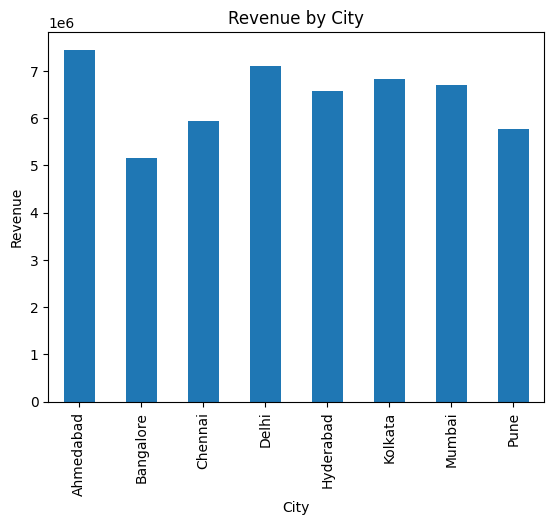

In [34]:
city_revenue = df.groupby('City')['Revenue'].sum()

city_revenue.plot(kind='bar')

plot.title("Revenue by City")
plot.xlabel("City")
plot.ylabel("Revenue")
plot.show()

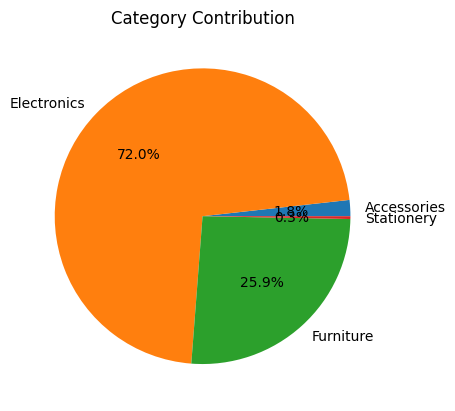

In [35]:
category_revenue.plot(kind='pie', autopct='%1.1f%%')

plot.title("Category Contribution")
plot.ylabel("")
plot.show()

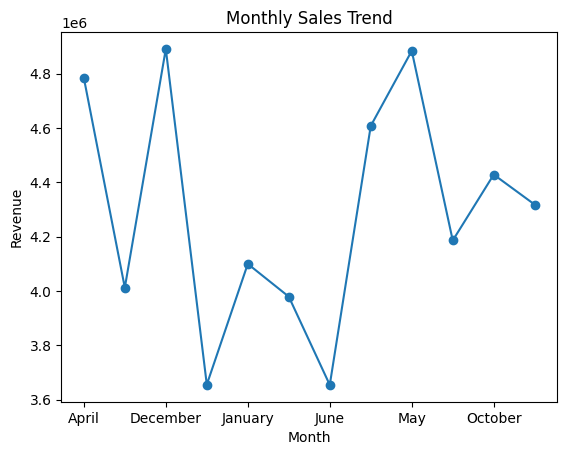

In [37]:
monthly_sales.plot(kind='line', marker='o')

plot.title("Monthly Sales Trend")
plot.xlabel("Month")
plot.ylabel("Revenue")
plot.show()

In [38]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print(top_products.head(3))

Product
Laptop     27105144
Sofa        8106368
Printer     4966315
Name: Revenue, dtype: int64


In [39]:
average_order_value = df['Revenue'].sum() / len(df)

print("Average Order Value:", average_order_value)

Average Order Value: 25750.655
